# Fitting

## Setup and configuration

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.grid": True,
})

TIME_COL = "Time_Relative_s"

MATERIAL = "PEI5mgmL"
TEMPERATURE = "60?C"
MODE = "Des"

def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "data_manipulated").exists():
            return path
    raise FileNotFoundError("Could not find the project root with data/data_manipulated.")


PROJECT_ROOT = find_project_root()
MANIPULATED_DATA_DIR = PROJECT_ROOT / "data" / "data_manipulated"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

SELECTED_MANIPULATED_FILE = f"{MATERIAL}_{TEMPERATURE}_{MODE}_manipulated.csv"
MANIPULATED_DATA_DIR / SELECTED_MANIPULATED_FILE


WindowsPath('c:/Users/Max/Documents/bachelor thesis/data/data_manipulated/PEI5mgmL_60?C_Abs_manipulated.csv')

## Load manipulated derivative data


In [134]:
def selected_temperature_token(temperature):
    return "".join(char for char in str(temperature) if char.isdigit())


def find_manipulated_derivative_file(
    data_dir=None,
    selected_file=None,
    material=None,
    temperature=None,
    mode=None,
):
    data_dir = MANIPULATED_DATA_DIR if data_dir is None else Path(data_dir)
    selected_file = SELECTED_MANIPULATED_FILE if selected_file is None else selected_file
    material = MATERIAL if material is None else material
    temperature = TEMPERATURE if temperature is None else temperature
    mode = MODE if mode is None else mode

    exact_path = data_dir / selected_file
    if exact_path.exists():
        return exact_path

    candidates = sorted(data_dir.glob(f"{material}_*_{mode}_manipulated.csv"))
    temp_token = selected_temperature_token(temperature)
    if temp_token:
        candidates = [path for path in candidates if selected_temperature_token(path.stem).find(temp_token) >= 0]

    if len(candidates) == 1:
        return candidates[0]
    if not candidates:
        raise FileNotFoundError(f"No manipulated dataset found for {material} {temperature} {mode} in {data_dir}")
    raise FileExistsError(f"Multiple manipulated datasets match {material} {temperature} {mode}: {candidates}")


def load_manipulated_derivative_data(path=None):
    path = find_manipulated_derivative_file() if path is None else Path(path)
    df = pd.read_csv(path)

    required_cols = {TIME_COL, "Omega_rad_s", "Freq_Hz_mid", "Eps_real_derivative"}
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        raise ValueError(f"Manipulated derivative data is missing columns: {sorted(missing_cols)}")

    if "Derivative_Manual_Removed" in df.columns:
        df = df[~df["Derivative_Manual_Removed"].fillna(False).astype(bool)].copy()

    df = df.dropna(subset=[TIME_COL, "Omega_rad_s", "Eps_real_derivative"]).copy()
    df = df[
        (df["Omega_rad_s"] > 0)
        & np.isfinite(df["Omega_rad_s"])
        & np.isfinite(df["Eps_real_derivative"])
        & np.isfinite(df[TIME_COL])
    ].copy()

    df["Data_Source"] = "manipulated_derivative"
    if "Source_File" not in df.columns:
        df["Source_File"] = path.name
    df.attrs["source_path"] = str(path)
    return df.sort_values([TIME_COL, "Omega_rad_s"]).reset_index(drop=True)


In [135]:
df_derivative = load_manipulated_derivative_data()

df_interpolated = pd.DataFrame()

print("Using manipulated derivative data")
print(f"Source: {df_derivative.attrs.get('source_path')}")
print(f"Derivative rows: {len(df_derivative):,}")
print(f"Time points: {df_derivative[TIME_COL].nunique():,}")
df_derivative.head()


Using manipulated derivative data
Source: c:\Users\Max\Documents\bachelor thesis\data\data_manipulated\PEI5mgmL_60°C_Abs_manipulated.csv
Derivative rows: 58,788
Time points: 3,266


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,Derivative_Point_Index,Freq_Hz_left,Freq_Hz_right,Eps_real_left,Eps_real_right,Freq_Hz_mid,Omega_rad_s,Eps_real_derivative,Derivative_Manual_Removed,Derivative_Manual_Removal_Reason,Data_Source
0,PEI5mgmL_60°C_Abs.TXT,PEI5mgmL,60°C,Abs,23,-345.28,0,100.00,150.00,6.312735,6.277546,122.474487,769.529898,0.136323,False,NaN,manipulated_derivative
1,PEI5mgmL_60°C_Abs.TXT,PEI5mgmL,60°C,Abs,23,-345.28,2,225.00,337.50,6.243200,6.211919,275.567596,1731.442271,0.121186,False,NaN,manipulated_derivative
2,PEI5mgmL_60°C_Abs.TXT,PEI5mgmL,60°C,Abs,23,-345.28,3,337.50,506.25,6.211919,6.181544,413.351394,2597.163406,0.117674,False,NaN,manipulated_derivative
3,PEI5mgmL_60°C_Abs.TXT,PEI5mgmL,60°C,Abs,23,-345.28,4,506.25,759.38,6.181544,6.151025,620.029132,3895.757935,0.118229,False,NaN,manipulated_derivative
4,PEI5mgmL_60°C_Abs.TXT,PEI5mgmL,60°C,Abs,23,-345.28,5,759.38,1139.10,6.151025,6.118258,930.059008,5843.733093,0.126933,False,NaN,manipulated_derivative


## Havriliak-Negami model with power-law baseline

In [136]:
TINY = 1e-30


HN_DERIVATIVE_STEP = 1e-4


def hn_peak_factor(alpha, beta):
    denominator = 2 + 2 * beta
    low_slope_term = np.sin(alpha * np.pi / denominator)
    high_slope_term = np.sin(alpha * beta * np.pi / denominator)
    return low_slope_term ** (1 / alpha) * high_slope_term ** (-1 / alpha)


def tau_hn_from_omega_p(alpha, beta, omega_p):
    return hn_peak_factor(alpha, beta) / omega_p


def beta_from_alpha_beta(alpha, alpha_beta):
    return alpha_beta / alpha


def hn_complex(w, de, alpha, beta, tau):
    return de / (1 + (1j * w * tau) ** alpha) ** beta


def hn_real_derivative(w, de, alpha, beta, tau):
    h = HN_DERIVATIVE_STEP
    eps_plus = np.real(hn_complex(w * np.exp(h), de, alpha, beta, tau))
    eps_minus = np.real(hn_complex(w * np.exp(-h), de, alpha, beta, tau))
    return -np.pi / 2 * (eps_plus - eps_minus) / (2 * h)


def power_law_baseline(w, amplitude, exponent):
    f = w / (2 * np.pi)
    return amplitude * f**exponent


def de_from_height(height, alpha, alpha_beta, omega_p):
    beta = beta_from_alpha_beta(alpha, alpha_beta)
    tau_hn = tau_hn_from_omega_p(alpha, beta, omega_p)
    unit_height = hn_real_derivative(np.asarray([omega_p]), 1.0, alpha, beta, tau_hn)[0]
    return height / max(unit_height, TINY)


def unpack_hn_params(params):
    height, alpha, alpha_beta, omega_p, der_A, der_m = params
    return height, alpha, alpha_beta, omega_p, der_A, der_m


def derived_hn_parameter_dict(params):
    height, alpha, alpha_beta, omega_p, der_A, der_m = unpack_hn_params(params)
    beta = beta_from_alpha_beta(alpha, alpha_beta)
    return {
        "beta": beta,
        "de": de_from_height(height, alpha, alpha_beta, omega_p),
        "tau_hn": tau_hn_from_omega_p(alpha, beta, omega_p),
    }


def derivative_linear_model(lnw, *params):
    height, alpha, alpha_beta, omega_p, der_A, der_m = unpack_hn_params(params)
    beta = beta_from_alpha_beta(alpha, alpha_beta)
    de = de_from_height(height, alpha, alpha_beta, omega_p)
    tau_hn = tau_hn_from_omega_p(alpha, beta, omega_p)
    w = np.exp(lnw)
    return hn_real_derivative(w, de, alpha, beta, tau_hn) + power_law_baseline(w, der_A, der_m)


def derivative_log_model(lnw, *params):
    return np.log(np.maximum(derivative_linear_model(lnw, *params), TINY))


# Parameters: HN peak height, alpha, alpha*beta, omega_p [rad/s], derivative A*f^m.
P0 = np.array([
    0.3, 0.7, 0.49, 1e5,
    5e-2, 0.0,
], dtype=float)

LOWER_BOUNDS = np.array([
    1e-10, 0.05, 0.05, 5e2,
    0.0, -5.0,
], dtype=float)

UPPER_BOUNDS = np.array([
    np.inf, 1.0, 1.0, 5e6,
    np.inf, 5.0,
], dtype=float)

PARAMETER_LABELS = [
    "height", "alpha", "alpha_beta", "omega_p",
    "der_A", "der_m",
]


DER_M_INDEX = PARAMETER_LABELS.index("der_m")


## Fit helpers

In [137]:
def clip_to_bounds(p0, lower_bounds=LOWER_BOUNDS, upper_bounds=UPPER_BOUNDS):
    p0 = np.asarray(p0, dtype=float)
    margin = 1e-9
    lower = np.asarray(lower_bounds, dtype=float).copy()
    upper = np.asarray(upper_bounds, dtype=float).copy()
    finite_lower = np.isfinite(lower)
    finite_upper = np.isfinite(upper)
    lower[finite_lower] += margin * np.maximum(1.0, np.abs(lower[finite_lower]))
    upper[finite_upper] -= margin * np.maximum(1.0, np.abs(upper[finite_upper]))
    return np.minimum(np.maximum(p0, lower), upper)


def make_sequential_bounds(reference_params, relative_change=0.1, absolute_changes=None):
    reference_params = np.asarray(reference_params, dtype=float)
    absolute_changes = absolute_changes or {}
    lower = np.empty_like(reference_params, dtype=float)
    upper = np.empty_like(reference_params, dtype=float)

    for i, name in enumerate(PARAMETER_LABELS):
        value = reference_params[i]
        if name in absolute_changes:
            delta = absolute_changes[name]
            local_lower = value - delta
            local_upper = value + delta
        else:
            local_lower, local_upper = np.sort([(1 - relative_change) * value, (1 + relative_change) * value])

        lower[i] = max(local_lower, LOWER_BOUNDS[i])
        upper[i] = min(local_upper, UPPER_BOUNDS[i])

    return lower, upper


def smooth_pilot_der_m(df_pilot, window=41):
    if df_pilot.empty or "der_m" not in df_pilot.columns:
        return pd.DataFrame(columns=["Time_Relative_s", "der_m", "der_m_smooth"])

    accepted = df_pilot[
        df_pilot["Accepted"]
        & np.isfinite(df_pilot["Time_Relative_s"])
        & np.isfinite(df_pilot["der_m"])
    ].copy()
    if accepted.empty:
        return pd.DataFrame(columns=["Time_Relative_s", "der_m", "der_m_smooth"])

    window = int(window)
    if window < 3:
        window = 3
    if window % 2 == 0:
        window += 1

    table = (
        accepted[["Time_Relative_s", "der_m"]]
        .groupby("Time_Relative_s", as_index=False)
        .median()
        .sort_values("Time_Relative_s")
        .reset_index(drop=True)
    )
    min_periods = max(3, window // 4)
    min_periods = min(min_periods, len(table))
    table["der_m_smooth"] = (
        table["der_m"]
        .rolling(window=window, center=True, min_periods=min_periods)
        .median()
        .interpolate(limit_direction="both")
        .bfill()
        .ffill()
    )
    return table


def der_m_target_at_time(der_m_table, time_s):
    if der_m_table is None or der_m_table.empty:
        return None
    times = der_m_table["Time_Relative_s"].to_numpy(dtype=float)
    values = der_m_table["der_m_smooth"].to_numpy(dtype=float)
    valid = np.isfinite(times) & np.isfinite(values)
    if not np.any(valid):
        return None
    return float(np.interp(float(time_s), times[valid], values[valid]))


def apply_der_m_local_bounds(fit_bounds, der_m_center, half_width):
    if der_m_center is None or half_width is None:
        return fit_bounds

    lower_bounds, upper_bounds = fit_bounds if fit_bounds is not None else (LOWER_BOUNDS, UPPER_BOUNDS)
    lower = np.asarray(lower_bounds, dtype=float).copy()
    upper = np.asarray(upper_bounds, dtype=float).copy()

    target_lower = max(float(der_m_center) - float(half_width), LOWER_BOUNDS[DER_M_INDEX])
    target_upper = min(float(der_m_center) + float(half_width), UPPER_BOUNDS[DER_M_INDEX])

    lower[DER_M_INDEX] = max(lower[DER_M_INDEX], target_lower)
    upper[DER_M_INDEX] = min(upper[DER_M_INDEX], target_upper)

    if lower[DER_M_INDEX] >= upper[DER_M_INDEX]:
        lower[DER_M_INDEX] = target_lower
        upper[DER_M_INDEX] = target_upper

    return lower, upper


def remove_der_m(values):
    return np.delete(np.asarray(values, dtype=float), DER_M_INDEX)


def insert_fixed_der_m(free_params, fixed_der_m):
    free_params = list(np.asarray(free_params, dtype=float))
    return np.asarray(
        free_params[:DER_M_INDEX] + [fixed_der_m] + free_params[DER_M_INDEX:],
        dtype=float,
    )


def prepare_fit_vectors(p0, fit_bounds=None, fixed_der_m=None):
    lower_bounds, upper_bounds = fit_bounds if fit_bounds is not None else (LOWER_BOUNDS, UPPER_BOUNDS)
    p0 = clip_to_bounds(p0, lower_bounds, upper_bounds)

    if fixed_der_m is None:
        return p0, lower_bounds, upper_bounds

    return (
        remove_der_m(p0),
        remove_der_m(lower_bounds),
        remove_der_m(upper_bounds),
    )


def fit_quality(y_data, y_fit, popt):
    residual = y_data - y_fit
    rmse_log = float(np.sqrt(np.nanmean(residual**2)))
    ss_res = float(np.nansum(residual**2))
    ss_tot = float(np.nansum((y_data - np.nanmean(y_data)) ** 2))
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    lower_hit = np.isclose(popt, LOWER_BOUNDS, rtol=1e-4, atol=1e-12)
    upper_hit = np.isclose(popt, UPPER_BOUNDS, rtol=1e-4, atol=1e-12)
    at_bounds = bool(np.any(lower_hit | upper_hit))
    return {
        "RMSE_Log": rmse_log,
        "R2": r2,
        "At_Bounds": at_bounds,
        "Bounds_Hit_Count": int(np.sum(lower_hit | upper_hit)),
    }


def is_fit_accepted(quality, max_rmse_log=1.0, min_r2=0.5, allow_bounds=False):
    if not np.isfinite(quality["RMSE_Log"]):
        return False
    if quality["RMSE_Log"] > max_rmse_log:
        return False
    if np.isfinite(quality["R2"]) and quality["R2"] < min_r2:
        return False
    if quality["At_Bounds"] and not allow_bounds:
        return False
    return True


def build_fit_data(fit_time_s):
    available_times = np.sort(df_derivative[TIME_COL].unique())
    plot_time = available_times[np.abs(available_times - fit_time_s).argmin()]

    derivative_df = df_derivative[df_derivative[TIME_COL] == plot_time].sort_values("Omega_rad_s")
    derivative_df = derivative_df[(derivative_df["Eps_real_derivative"] > 0) & np.isfinite(derivative_df["Eps_real_derivative"])]
    x_der = np.log(derivative_df["Omega_rad_s"].to_numpy())
    y_der = np.log(derivative_df["Eps_real_derivative"].to_numpy())

    return plot_time, x_der, y_der, derivative_log_model, derivative_df


def fit_spectrum_at_time(
    fit_time_s,
    p0=P0,
    max_rmse_log=1.0,
    min_r2=0.5,
    allow_bounds=False,
    fit_bounds=None,
    fixed_der_m=None,
):
    plot_time, x_fit, y_data, model, derivative_df = build_fit_data(fit_time_s)
    p0_fit, lower_fit, upper_fit = prepare_fit_vectors(
        p0,
        fit_bounds=fit_bounds,
        fixed_der_m=fixed_der_m,
    )

    if fixed_der_m is None:
        fit_model = model
    else:
        fit_model = lambda lnw, *free_params: model(lnw, *insert_fixed_der_m(free_params, fixed_der_m))

    popt, pcov = curve_fit(
        fit_model,
        x_fit,
        y_data,
        p0=p0_fit,
        bounds=(lower_fit, upper_fit),
        maxfev=50000,
    )
    if fixed_der_m is not None:
        popt = insert_fixed_der_m(popt, fixed_der_m)

    quality = fit_quality(y_data, model(x_fit, *popt), popt)
    lower_bounds, upper_bounds = fit_bounds if fit_bounds is not None else (LOWER_BOUNDS, UPPER_BOUNDS)
    local_lower_hit = np.isclose(popt, lower_bounds, rtol=1e-4, atol=1e-12)
    local_upper_hit = np.isclose(popt, upper_bounds, rtol=1e-4, atol=1e-12)
    if fixed_der_m is not None:
        local_lower_hit[DER_M_INDEX] = False
        local_upper_hit[DER_M_INDEX] = False
    quality["Sequential_Bounds"] = fit_bounds is not None
    quality["Sequential_Bounds_Hit_Count"] = int(np.sum(local_lower_hit | local_upper_hit))
    quality["Fixed_der_m"] = fixed_der_m
    quality["Accepted"] = is_fit_accepted(
        quality,
        max_rmse_log=max_rmse_log,
        min_r2=min_r2,
        allow_bounds=allow_bounds,
    )
    return plot_time, popt, pcov, derivative_df, quality

## Plot helpers

In [138]:
def plot_single_fit(fit_time, popt, derivative_df):
    w_plot = np.logspace(
        np.log10(derivative_df["Omega_rad_s"].min()),
        np.log10(derivative_df["Omega_rad_s"].max()),
        400,
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        derivative_df["Omega_rad_s"],
        derivative_df["Eps_real_derivative"],
        color="black",
        label="Interpolated-spectrum derivative",
    )

    height, alpha, alpha_beta, omega_p, der_A, der_m = unpack_hn_params(popt)
    beta = beta_from_alpha_beta(alpha, alpha_beta)
    de = de_from_height(height, alpha, alpha_beta, omega_p)
    tau_hn = tau_hn_from_omega_p(alpha, beta, omega_p)
    hn_fit = hn_real_derivative(w_plot, de, alpha, beta, tau_hn)
    baseline_fit = power_law_baseline(w_plot, der_A, der_m)
    fit_total = hn_fit + baseline_fit

    ax.plot(w_plot, fit_total, color="red", linewidth=2.2, label="HN + A f^m")
    ax.plot(w_plot, hn_fit, linestyle="--", linewidth=1.4, label="HN relaxation")
    baseline_positive = np.where(baseline_fit > 0, baseline_fit, np.nan)
    ax.plot(w_plot, baseline_positive, linestyle=":", linewidth=1.4, label="A f^m baseline")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Angular frequency omega (rad/s)")
    ax.set_ylabel("Eps real derivative")
    ax.set_title(f"Fit at t_rel = {fit_time:.2f} s | {MATERIAL} {TEMPERATURE} {MODE}")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_fit_from_parameter_row(row):
    from IPython.display import display

    fit_time = float(row["Time_Relative_s"])
    _, _, _, _, derivative_df = build_fit_data(fit_time)
    params = row[PARAMETER_LABELS].to_numpy(dtype=float)

    w_plot = np.logspace(
        np.log10(derivative_df["Omega_rad_s"].min()),
        np.log10(derivative_df["Omega_rad_s"].max()),
        500,
    )

    height, alpha, alpha_beta, omega_p, der_A, der_m = unpack_hn_params(params)
    beta = beta_from_alpha_beta(alpha, alpha_beta)
    de = de_from_height(height, alpha, alpha_beta, omega_p)
    tau_hn = tau_hn_from_omega_p(alpha, beta, omega_p)
    hn_fit = hn_real_derivative(w_plot, de, alpha, beta, tau_hn)
    baseline_fit = power_law_baseline(w_plot, der_A, der_m)
    fit_total = hn_fit + baseline_fit

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        derivative_df["Omega_rad_s"],
        derivative_df["Eps_real_derivative"],
        color="black",
        s=22,
        label="Data",
    )
    ax.plot(w_plot, fit_total, color="red", linewidth=2.2, label="HN + A f^m")
    ax.plot(w_plot, hn_fit, linestyle="--", linewidth=1.5, label="HN relaxation")
    ax.plot(
        w_plot,
        np.where(baseline_fit > 0, baseline_fit, np.nan),
        linestyle=":",
        linewidth=1.5,
        label="A f^m baseline",
    )
    ax.axvline(omega_p, color="tab:blue", linestyle="--", linewidth=1.2, alpha=0.8, label="omega_p")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Angular frequency omega (rad/s)")
    ax.set_ylabel("Eps real derivative")
    fit_time_min = fit_time / 60
    title = f"Fit at t_rel = {fit_time:.2f} s ({fit_time_min:.2f} min) | {MATERIAL} {TEMPERATURE} {MODE}"
    if "RMSE_Log" in row and np.isfinite(row["RMSE_Log"]):
        title += f" | RMSE_log={row['RMSE_Log']:.4g}"
    if "R2" in row and np.isfinite(row["R2"]):
        title += f", R2={row['R2']:.5g}"
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    summary_cols = [
        "Time_Relative_s", "height", "omega_p", "alpha", "alpha_beta", "beta", "de", "tau_hn",
        "der_A", "der_m", "RMSE_Log", "R2", "Accepted", "Direction",
    ]
    summary_cols = [col for col in summary_cols if col in row.index]
    summary = row[summary_cols].copy()
    if "Time_Relative_s" in summary.index:
        position = summary.index.get_loc("Time_Relative_s") + 1
        summary = pd.concat([
            summary.iloc[:position],
            pd.Series({"Time_Relative_min": fit_time_min}),
            summary.iloc[position:],
        ])
    display(pd.DataFrame({"value": summary}))


def close_fit_viewer(viewer):
    if not viewer:
        return
    for key in ("container", "controls", "slider", "time_label", "output"):
        widget = viewer.get(key) if isinstance(viewer, dict) else None
        if widget is not None and hasattr(widget, "close"):
            widget.close()


def plot_time_series_fit_viewer(df_fit_parameters, plot_only_accepted=True):
    if df_fit_parameters.empty:
        print("No time-series fit is available. Run the time-series fit first.")
        return None

    plot_df = df_fit_parameters[df_fit_parameters["Fit_Success"]].copy()
    if plot_only_accepted:
        plot_df = plot_df[plot_df["Accepted"]]
    plot_df = plot_df.sort_values("Time_Relative_s").reset_index(drop=True)

    if plot_df.empty:
        print("No successful fit rows are available for the interactive viewer.")
        return None

    try:
        import ipywidgets as widgets
        from IPython.display import Javascript, clear_output, display
    except ImportError:
        print("ipywidgets is not installed. Showing the first available fit instead.")
        plot_fit_from_parameter_row(plot_df.iloc[0])
        return None

    cleanup_js = """
    (() => {
      const outputSelectors = ['.jp-OutputArea-output', '.output_subarea', '.output'];
      const outputs = new Set();
      for (const selector of outputSelectors) {
        document.querySelectorAll(selector).forEach(node => outputs.add(node));
      }
      for (const output of outputs) {
        const hasCurrentViewer = output.querySelector('.fit-viewer-root');
        const text = output.textContent || '';
        const looksLikeOldViewer = text.includes('t_rel:') && text.includes('accepted:') && text.includes('Index');
        if (hasCurrentViewer || looksLikeOldViewer) {
          output.remove();
        }
      }
    })();
    """

    clear_output(wait=True)
    display(Javascript(cleanup_js))

    initial_index = int(np.abs(plot_df["Time_Relative_s"].to_numpy() - FIT_REFERENCE_TIME_S).argmin())
    slider = widgets.IntSlider(
        value=initial_index,
        min=0,
        max=len(plot_df) - 1,
        step=1,
        description="Index",
        continuous_update=False,
        readout=True,
    )
    time_label = widgets.HTML()
    output = widgets.Output()

    def update_time_label(index):
        row = plot_df.iloc[int(index)]
        time_s = float(row["Time_Relative_s"])
        time_min = time_s / 60
        time_label.value = (
            f"<b>t_rel:</b> {time_s:.2f} s ({time_min:.2f} min) "
            f"&nbsp; <b>accepted:</b> {bool(row['Accepted'])}"
        )

    def draw(index):
        update_time_label(index)
        with output:
            clear_output(wait=True)
            plot_fit_from_parameter_row(plot_df.iloc[int(index)])

    slider.observe(lambda change: draw(change["new"]), names="value")
    controls = widgets.HBox([slider, time_label])
    container = widgets.VBox([controls, output])
    container.add_class("fit-viewer-root")

    global ACTIVE_FIT_VIEWER
    ACTIVE_FIT_VIEWER = {
        "container": container,
        "controls": controls,
        "slider": slider,
        "time_label": time_label,
        "output": output,
        "data": plot_df,
    }
    display(container)
    draw(slider.value)
    return ACTIVE_FIT_VIEWER


def symlog_linthresh_from_times(times, fallback=1.0):
    times = np.asarray(times, dtype=float)
    nonzero_abs_times = np.abs(times[np.isfinite(times) & ~np.isclose(times, 0)])
    if len(nonzero_abs_times) == 0:
        return fallback
    return max(float(np.nanmin(nonzero_abs_times)), fallback)


def plot_fit_parameter_time_series(
    df_fit_parameters,
    parameters=("height", "omega_p", "alpha", "alpha_beta", "der_A", "der_m", "beta", "de"),
    plot_only_accepted=True,
):
    if df_fit_parameters.empty:
        print("No time-series fit is available. Run the time-series fit with RUN_TIME_SERIES_FIT = True first.")
        return

    plot_params = df_fit_parameters[df_fit_parameters["Fit_Success"]].copy()
    if plot_only_accepted:
        plot_params = plot_params[plot_params["Accepted"]]

    print(
        df_fit_parameters.groupby(["Fit_Success", "Accepted"], dropna=False)
        .size()
        .rename("count")
        .reset_index()
    )

    for parameter in parameters:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(plot_params["Time_Relative_s"], plot_params[parameter], marker="o", label=parameter)
        if parameter == "der_m" and "Target_der_m" in plot_params.columns:
            target = plot_params["Target_der_m"]
            if target.notna().any():
                ax.plot(
                    plot_params["Time_Relative_s"],
                    target,
                    color="red",
                    linewidth=2,
                    label="Smoothed pilot der_m",
                )
                if "Der_m_Bound_Half_Width" in plot_params.columns:
                    half_width = plot_params["Der_m_Bound_Half_Width"]
                    if half_width.notna().any():
                        ax.fill_between(
                            plot_params["Time_Relative_s"],
                            target - half_width,
                            target + half_width,
                            color="red",
                            alpha=0.12,
                            label="der_m bound",
                        )
                ax.legend()
        if parameter in {"height", "omega_p", "tau_hn", "der_A", "de"}:
            ax.set_yscale("log")
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("Time relative to atmosphere switch (s)")
        ax.set_ylabel(parameter)
        ax.set_title(f"Parameter over time: {parameter} | {MATERIAL} {TEMPERATURE} {MODE}")
        plt.tight_layout()
        plt.show()

    if "de" in plot_params.columns:
        de_plot = plot_params[plot_params["de"] > 0].copy()
        if de_plot.empty:
            print("No positive delta epsilon values are available for the logarithmic delta epsilon plot.")
        else:
            fig, ax = plt.subplots(figsize=(11, 7))
            de_plot = de_plot.sort_values("Time_Relative_s")
            ax.plot(
                de_plot["Time_Relative_s"],
                de_plot["de"],
                marker="o",
                markersize=2.5,
                linewidth=1,
                label="Delta epsilon",
            )
            ax.set_xscale("symlog", linthresh=1)
            ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
            ax.set_xlabel("Time relative to atmosphere switch (s, symlog scale)")
            ax.set_ylabel("Delta epsilon")
            ax.set_title("Delta epsilon over time from fit parameters")
            ax.grid(True, alpha=0.3)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

    quality_cols = ["Time_Relative_s", "Direction", "Fit_Success", "Accepted", "RMSE_Log", "R2", "At_Bounds", "Bounds_Hit_Count"]
    print(df_fit_parameters[quality_cols].head(20))

def plot_pilot_der_m_guidance(df_pilot, df_smooth=None):
    if df_pilot.empty or "der_m" not in df_pilot.columns:
        print("No pilot fit with free der_m is available.")
        return

    plot_params = df_pilot[df_pilot["Fit_Success"]].copy()
    accepted = plot_params[plot_params["Accepted"] & np.isfinite(plot_params["der_m"])]
    if accepted.empty:
        print("Pilot fit has no accepted der_m values.")
        return

    median_der_m = float(accepted["der_m"].median())
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        accepted["Time_Relative_s"],
        accepted["der_m"],
        marker="o",
        linestyle="none",
        markersize=3,
        alpha=0.45,
        label="Pilot der_m",
    )
    if df_smooth is not None and not df_smooth.empty:
        ax.plot(
            df_smooth["Time_Relative_s"],
            df_smooth["der_m_smooth"],
            color="red",
            linewidth=2,
            label="Smoothed pilot der_m",
        )
        if "DER_M_LOCAL_BOUND_HALF_WIDTH" in globals():
            ax.fill_between(
                df_smooth["Time_Relative_s"],
                df_smooth["der_m_smooth"] - DER_M_LOCAL_BOUND_HALF_WIDTH,
                df_smooth["der_m_smooth"] + DER_M_LOCAL_BOUND_HALF_WIDTH,
                color="red",
                alpha=0.12,
                label="Final der_m bound",
            )
    ax.axhline(
        median_der_m,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        label=f"Global median = {median_der_m:.4g}",
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Time relative to atmosphere switch (s)")
    ax.set_ylabel("der_m")
    ax.set_title(f"Pilot der_m guidance for final fit | {MATERIAL} {TEMPERATURE} {MODE}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_pilot_der_m_median(df_pilot):
    plot_pilot_der_m_guidance(df_pilot)


In [139]:
print("Interactive fit viewer is created after the time-series fit.")


Interactive fit viewer is created after the time-series fit.


## Time-series fit

In [140]:
RUN_TIME_SERIES_FIT = True
USE_FIT_CACHE = True
FORCE_REFIT = False

FIT_REFERENCE_TIME_S = 1000

MAX_RMSE_LOG = 1.0
MIN_R2 = 0.5
ALLOW_BOUND_HITS = True

FIT_DER_M_FROM_PILOT = True
FIXED_DER_M = None
DER_M_PILOT_SMOOTH_WINDOW = 100
DER_M_LOCAL_BOUND_HALF_WIDTH = 0.01

USE_SEQUENTIAL_BOUNDS = True
SEQUENTIAL_RELATIVE_CHANGE = 0.1
SEQUENTIAL_ABSOLUTE_CHANGES = {
    "alpha": 0.1,
    "alpha_beta": 0.1,
    "der_m": 0.1,
}

FIT_CACHE_KEY = f"{MATERIAL}_{selected_temperature_token(TEMPERATURE)}C_{MODE}"
FIT_PARAMETERS_CSV = RESULTS_DIR / f"fit_parameters_{FIT_CACHE_KEY}.csv"
FIT_PARAMETERS_PILOT_CSV = RESULTS_DIR / f"fit_parameters_pilot_{FIT_CACHE_KEY}.csv"
PILOT_DER_M_SMOOTH_CSV = RESULTS_DIR / f"pilot_der_m_smooth_{FIT_CACHE_KEY}.csv"


def read_cached_fit_csv(path):
    path = Path(path)
    if not path.exists():
        return None
    return pd.read_csv(path)


def cache_available():
    required_paths = [FIT_PARAMETERS_CSV]
    if FIT_DER_M_FROM_PILOT:
        required_paths.extend([FIT_PARAMETERS_PILOT_CSV, PILOT_DER_M_SMOOTH_CSV])
    return all(path.exists() for path in required_paths)


def save_fit_cache(df_fit_parameters, df_fit_parameters_pilot=None, df_pilot_der_m_smooth=None):
    RESULTS_DIR.mkdir(exist_ok=True)
    df_fit_parameters.to_csv(FIT_PARAMETERS_CSV, index=False)
    print(f"Saved final fit parameters to: {FIT_PARAMETERS_CSV}")

    if df_fit_parameters_pilot is not None and not df_fit_parameters_pilot.empty:
        df_fit_parameters_pilot.to_csv(FIT_PARAMETERS_PILOT_CSV, index=False)
        print(f"Saved pilot fit parameters to: {FIT_PARAMETERS_PILOT_CSV}")

    if df_pilot_der_m_smooth is not None and not df_pilot_der_m_smooth.empty:
        df_pilot_der_m_smooth.to_csv(PILOT_DER_M_SMOOTH_CSV, index=False)
        print(f"Saved smoothed pilot der_m to: {PILOT_DER_M_SMOOTH_CSV}")


def load_fit_cache():
    df_fit_parameters = read_cached_fit_csv(FIT_PARAMETERS_CSV)
    df_fit_parameters_pilot = read_cached_fit_csv(FIT_PARAMETERS_PILOT_CSV)
    df_pilot_der_m_smooth = read_cached_fit_csv(PILOT_DER_M_SMOOTH_CSV)

    if df_fit_parameters is None:
        raise FileNotFoundError(f"Missing cached fit parameters: {FIT_PARAMETERS_CSV}")
    if df_fit_parameters_pilot is None:
        df_fit_parameters_pilot = pd.DataFrame()
    if df_pilot_der_m_smooth is None:
        df_pilot_der_m_smooth = pd.DataFrame()

    print(f"Loaded final fit parameters from: {FIT_PARAMETERS_CSV}")
    if not df_fit_parameters_pilot.empty:
        print(f"Loaded pilot fit parameters from: {FIT_PARAMETERS_PILOT_CSV}")
    if not df_pilot_der_m_smooth.empty:
        print(f"Loaded smoothed pilot der_m from: {PILOT_DER_M_SMOOTH_CSV}")

    return df_fit_parameters, df_fit_parameters_pilot, df_pilot_der_m_smooth


def fit_time_sequence(
    times,
    start_p0,
    direction_label,
    fixed_der_m=None,
    der_m_table=None,
    der_m_half_width=None,
    run_label="final",
):
    rows = []
    p0_current = start_p0.copy()

    for time_s in times:
        try:
            fit_bounds = None
            if USE_SEQUENTIAL_BOUNDS:
                fit_bounds = make_sequential_bounds(
                    p0_current,
                    relative_change=SEQUENTIAL_RELATIVE_CHANGE,
                    absolute_changes=SEQUENTIAL_ABSOLUTE_CHANGES,
                )

            target_der_m = der_m_target_at_time(der_m_table, time_s)
            fit_bounds = apply_der_m_local_bounds(fit_bounds, target_der_m, der_m_half_width)

            actual_time, popt_i, _, _, quality = fit_spectrum_at_time(
                time_s,
                p0=p0_current,
                max_rmse_log=MAX_RMSE_LOG,
                min_r2=MIN_R2,
                allow_bounds=ALLOW_BOUND_HITS,
                fit_bounds=fit_bounds,
                fixed_der_m=fixed_der_m,
            )
            row = {
                "Time_Relative_s": actual_time,
                "Fit_Success": True,
                "Direction": direction_label,
                "Run_Label": run_label,
                "Target_der_m": target_der_m,
                "Der_m_Bound_Half_Width": der_m_half_width,
                **quality,
            }
            row.update(dict(zip(PARAMETER_LABELS, popt_i)))
            row.update(derived_hn_parameter_dict(popt_i))

            if quality["Accepted"]:
                p0_current = popt_i
        except Exception as err:
            row = {
                "Time_Relative_s": time_s,
                "Fit_Success": False,
                "Accepted": False,
                "Direction": direction_label,
                "Run_Label": run_label,
                "Error": str(err),
            }
        rows.append(row)

    return rows


def run_time_series_fit(fixed_der_m=None, der_m_table=None, der_m_half_width=None, run_label="final"):
    all_times = np.sort(df_derivative[TIME_COL].unique())

    if len(all_times) == 0:
        raise ValueError("No time points found in the selected fit window.")

    reference_time = all_times[np.abs(all_times - FIT_REFERENCE_TIME_S).argmin()]
    reference_target_der_m = der_m_target_at_time(der_m_table, reference_time)
    reference_bounds = apply_der_m_local_bounds(None, reference_target_der_m, der_m_half_width)
    reference_time, reference_popt, _, _, reference_quality = fit_spectrum_at_time(
        reference_time,
        p0=P0,
        max_rmse_log=MAX_RMSE_LOG,
        min_r2=MIN_R2,
        allow_bounds=ALLOW_BOUND_HITS,
        fit_bounds=reference_bounds,
        fixed_der_m=fixed_der_m,
    )

    rows = []
    reference_row = {
        "Time_Relative_s": reference_time,
        "Fit_Success": True,
        "Direction": "reference",
        "Run_Label": run_label,
        "Target_der_m": reference_target_der_m,
        "Der_m_Bound_Half_Width": der_m_half_width,
        **reference_quality,
    }
    reference_row.update(dict(zip(PARAMETER_LABELS, reference_popt)))
    reference_row.update(derived_hn_parameter_dict(reference_popt))
    rows.append(reference_row)

    future_times = all_times[all_times > reference_time]
    past_times = all_times[all_times < reference_time][::-1]

    rows.extend(fit_time_sequence(
        future_times,
        reference_popt,
        "forward",
        fixed_der_m=fixed_der_m,
        der_m_table=der_m_table,
        der_m_half_width=der_m_half_width,
        run_label=run_label,
    ))
    rows.extend(fit_time_sequence(
        past_times,
        reference_popt,
        "backward",
        fixed_der_m=fixed_der_m,
        der_m_table=der_m_table,
        der_m_half_width=der_m_half_width,
        run_label=run_label,
    ))

    return (
        pd.DataFrame(rows)
        .sort_values("Time_Relative_s")
        .reset_index(drop=True)
    )


if RUN_TIME_SERIES_FIT:
    if USE_FIT_CACHE and not FORCE_REFIT and cache_available():
        df_fit_parameters, df_fit_parameters_pilot, df_pilot_der_m_smooth = load_fit_cache()
    else:
        df_fit_parameters_pilot = pd.DataFrame()
        df_pilot_der_m_smooth = pd.DataFrame()
        active_fixed_der_m = FIXED_DER_M
        active_der_m_table = None
        active_der_m_half_width = None

        if FIT_DER_M_FROM_PILOT:
            df_fit_parameters_pilot = run_time_series_fit(fixed_der_m=None, run_label="pilot_free_der_m")
            df_pilot_der_m_smooth = smooth_pilot_der_m(
                df_fit_parameters_pilot,
                window=DER_M_PILOT_SMOOTH_WINDOW,
            )
            if df_pilot_der_m_smooth.empty:
                raise ValueError("Pilot fit did not produce accepted der_m values.")
            active_der_m_table = df_pilot_der_m_smooth
            active_der_m_half_width = DER_M_LOCAL_BOUND_HALF_WIDTH
            print(
                "Pilot der_m smoothed for final local bounds: "
                f"window={DER_M_PILOT_SMOOTH_WINDOW}, half_width={DER_M_LOCAL_BOUND_HALF_WIDTH}"
            )

        df_fit_parameters = run_time_series_fit(
            fixed_der_m=active_fixed_der_m,
            der_m_table=active_der_m_table,
            der_m_half_width=active_der_m_half_width,
            run_label="final_local_der_m_bounds" if active_der_m_table is not None else "final",
        )
        print("Time-series fit finished. Inspect the plots, then use the final export cell if you want to save the results.")

    df_fit_parameters.attrs["fixed_der_m"] = FIXED_DER_M
    df_fit_parameters.attrs["pilot_fit_available"] = not df_fit_parameters_pilot.empty
    df_fit_parameters.attrs["der_m_strategy"] = "local_smoothed_pilot_bounds" if FIT_DER_M_FROM_PILOT else "free_or_fixed"
    df_fit_parameters.attrs["der_m_local_bound_half_width"] = DER_M_LOCAL_BOUND_HALF_WIDTH if FIT_DER_M_FROM_PILOT else None

    print(df_fit_parameters.head())
else:
    df_fit_parameters = pd.DataFrame()
    df_fit_parameters_pilot = pd.DataFrame()
    df_pilot_der_m_smooth = pd.DataFrame()
    print("Time-series fit is disabled. Set RUN_TIME_SERIES_FIT = True to fit all selected time points.")


Pilot der_m smoothed for final local bounds: window=100, half_width=0.01
Time-series fit finished. Inspect the plots, then use the final export cell if you want to save the results.
   Time_Relative_s  Fit_Success Direction                 Run_Label  \
0          -345.28         True  backward  final_local_der_m_bounds   
1          -338.30         True  backward  final_local_der_m_bounds   
2          -335.83         True  backward  final_local_der_m_bounds   
3          -333.08         True  backward  final_local_der_m_bounds   
4          -330.34         True  backward  final_local_der_m_bounds   

   Target_der_m  Der_m_Bound_Half_Width  RMSE_Log        R2  At_Bounds  \
0     -0.251437                    0.01  0.015730  0.999697      False   
1     -0.251406                    0.01  0.015806  0.999694      False   
2     -0.251374                    0.01  0.015845  0.999692      False   
3     -0.250778                    0.01  0.015845  0.999692      False   
4     -0.250183      

## Interactive fit viewer


In [141]:
fit_viewer = plot_time_series_fit_viewer(df_fit_parameters, plot_only_accepted=True)


<IPython.core.display.Javascript object>

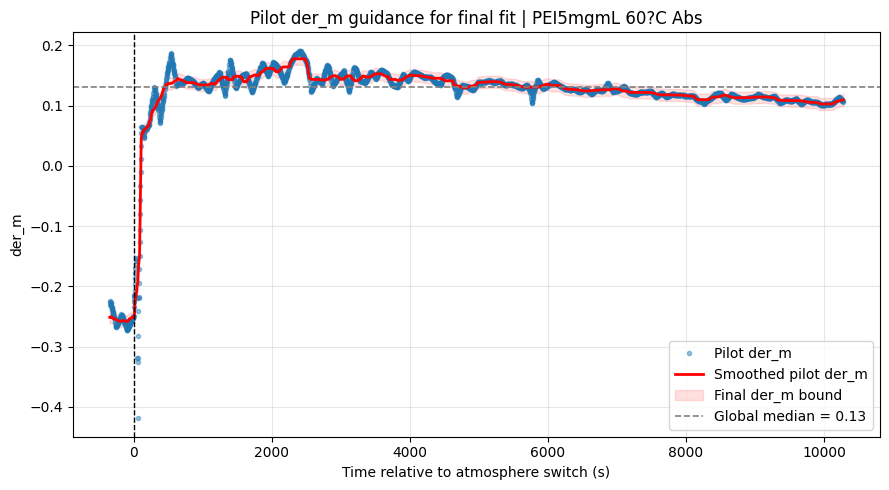

   Fit_Success  Accepted  count
0         True      True   3266


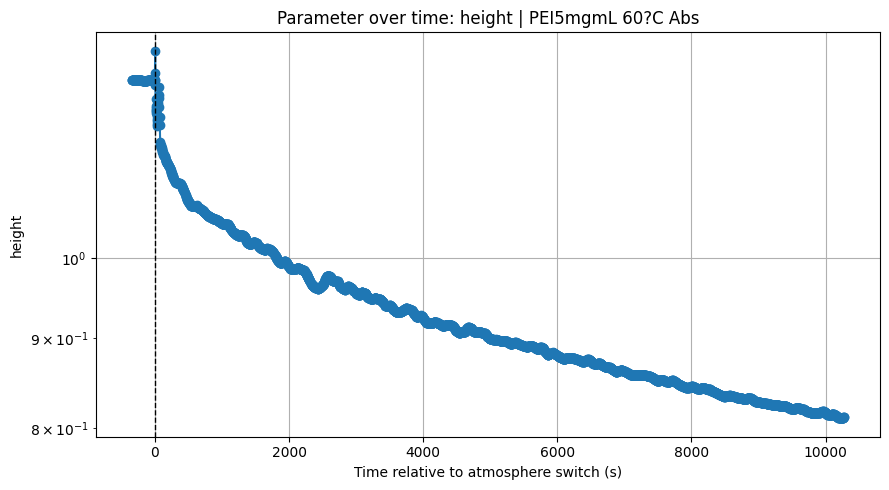

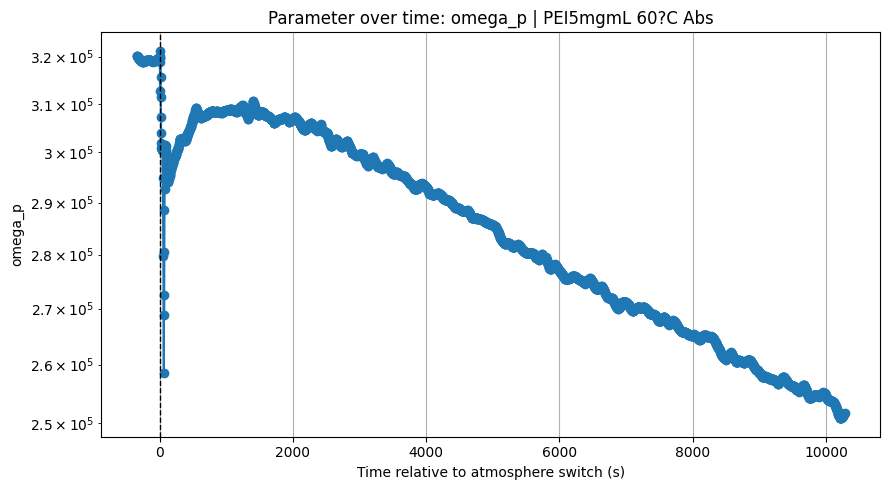

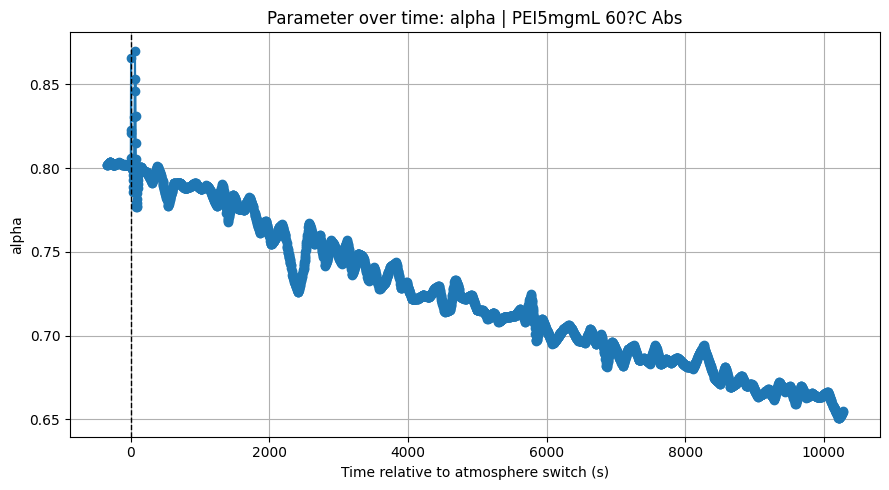

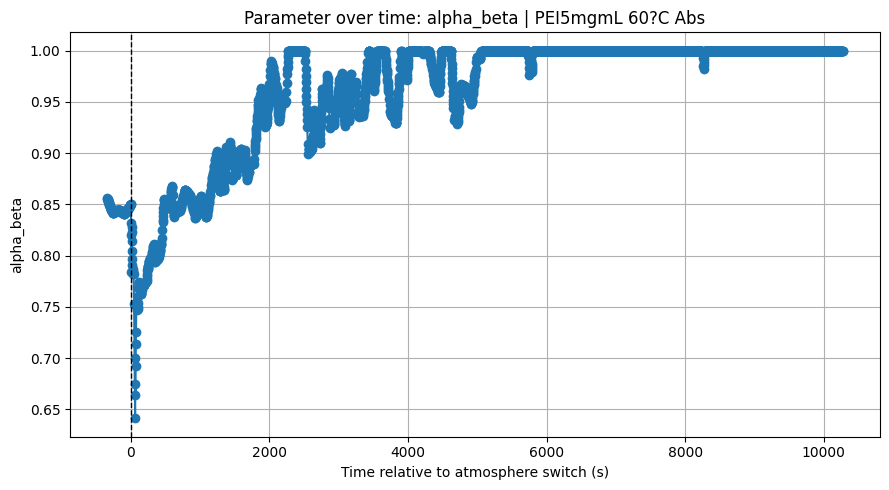

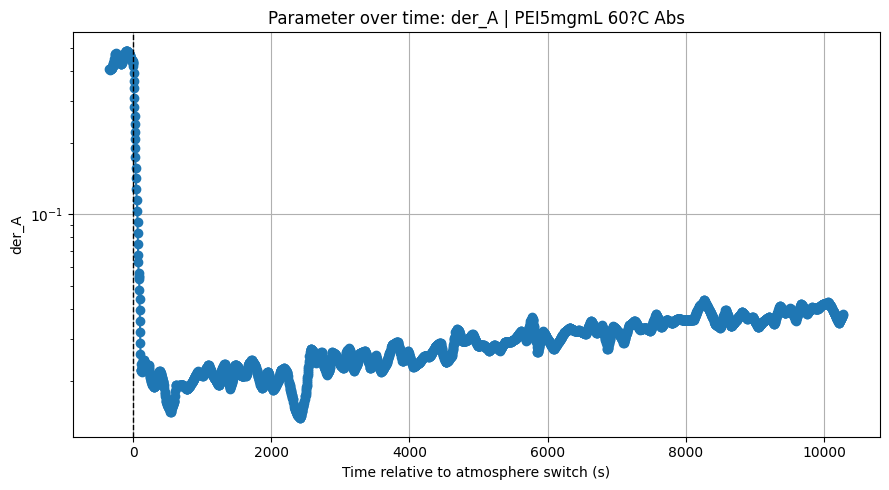

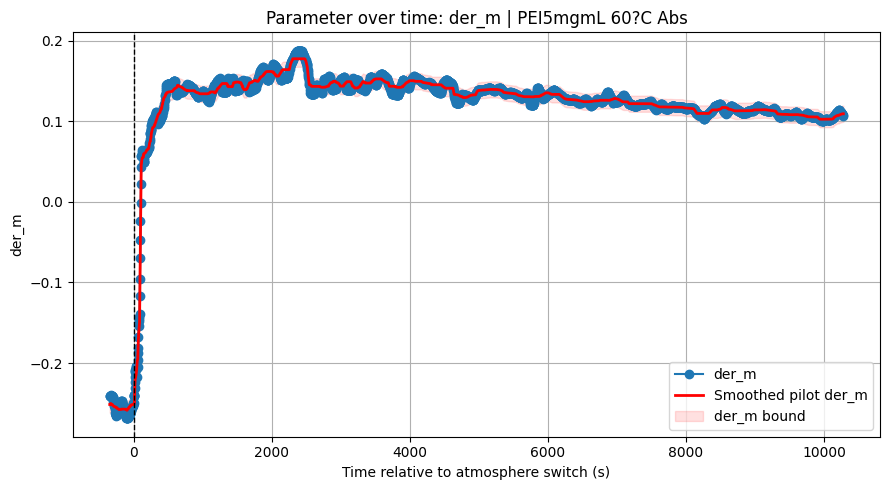

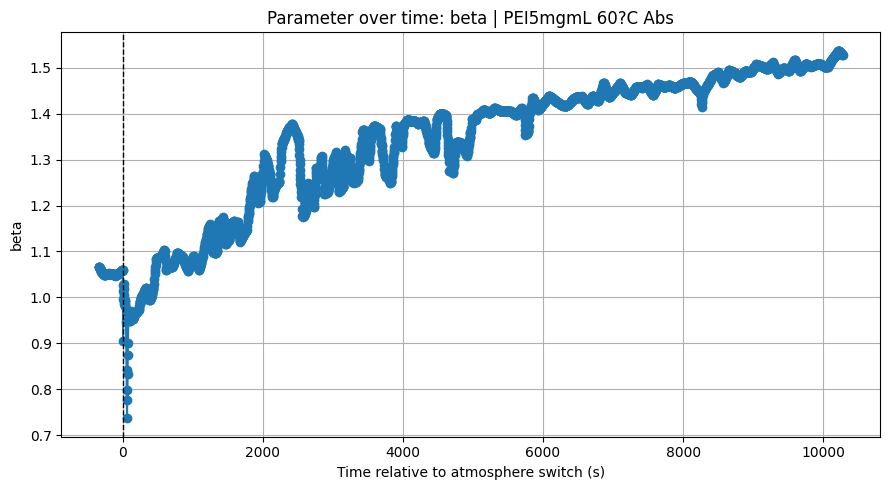

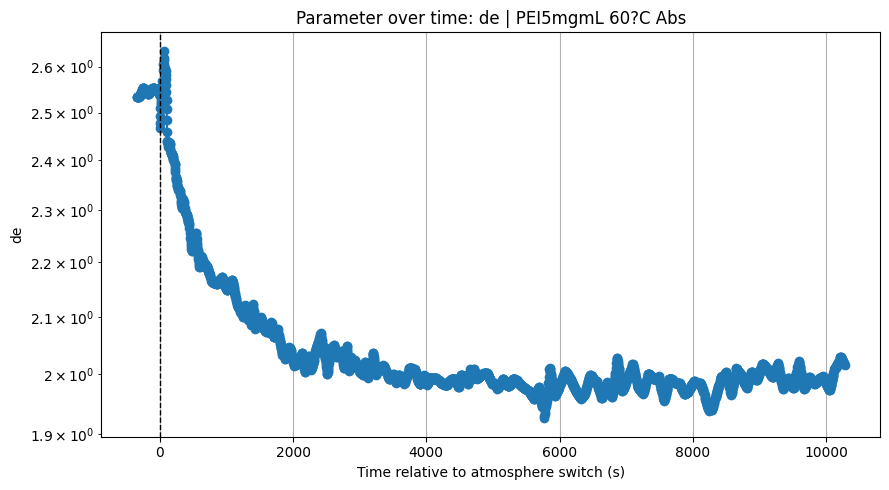

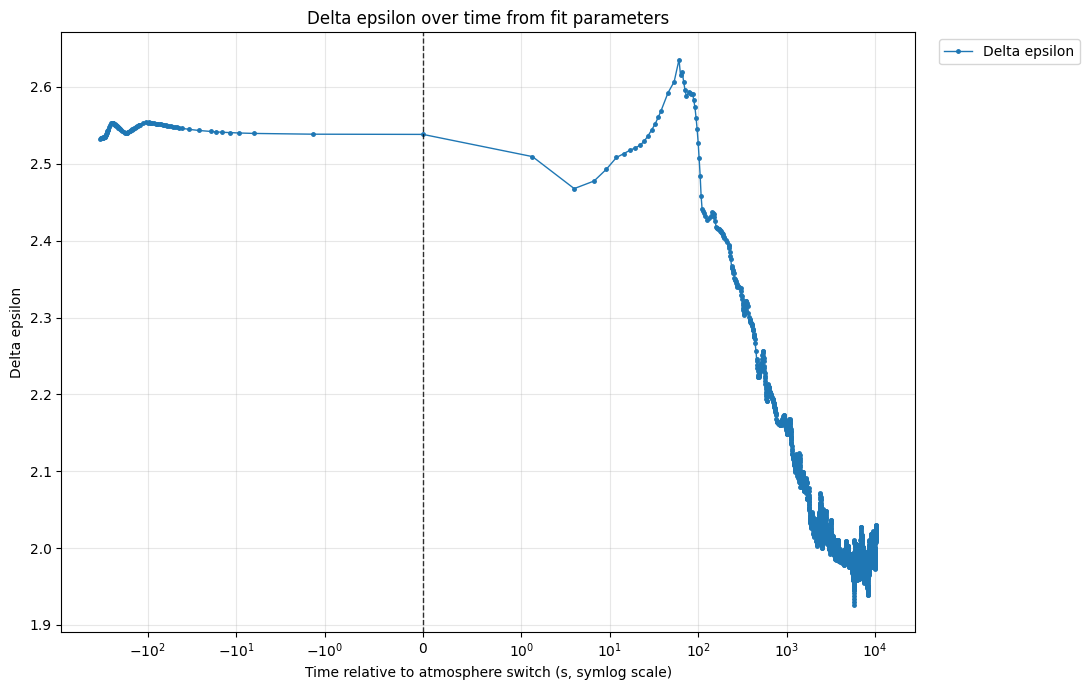

    Time_Relative_s Direction  Fit_Success  Accepted  RMSE_Log        R2  \
0           -345.28  backward         True      True  0.015730  0.999697   
1           -338.30  backward         True      True  0.015806  0.999694   
2           -335.83  backward         True      True  0.015845  0.999692   
3           -333.08  backward         True      True  0.015845  0.999692   
4           -330.34  backward         True      True  0.015862  0.999691   
5           -327.61  backward         True      True  0.015927  0.999689   
6           -324.97  backward         True      True  0.015995  0.999686   
7           -319.91  backward         True      True  0.016124  0.999681   
8           -317.47  backward         True      True  0.016194  0.999678   
9           -314.66  backward         True      True  0.016277  0.999674   
10          -312.22  backward         True      True  0.016355  0.999671   
11          -309.55  backward         True      True  0.016448  0.999667   
12          

In [142]:
plot_pilot_der_m_guidance(df_fit_parameters_pilot, df_pilot_der_m_smooth)

plot_fit_parameter_time_series(
    df_fit_parameters,
    parameters=("height", "omega_p", "alpha", "alpha_beta", "der_A", "der_m", "beta", "de"),
    plot_only_accepted=True,
)

## Save fit results


In [143]:
SAVE_FIT_RESULTS = True

if SAVE_FIT_RESULTS:
    if "df_fit_parameters" not in globals() or df_fit_parameters.empty:
        raise ValueError("No fit parameters available. Run the time-series fit before saving.")
    save_fit_cache(df_fit_parameters, df_fit_parameters_pilot, df_pilot_der_m_smooth)
else:
    print("Export disabled. Set SAVE_FIT_RESULTS = True in this cell when the inspected fit results look good.")


Saved final fit parameters to: c:\Users\Max\Documents\bachelor thesis\results\fit_parameters_PEI5mgmL_60C_Abs.csv
Saved pilot fit parameters to: c:\Users\Max\Documents\bachelor thesis\results\fit_parameters_pilot_PEI5mgmL_60C_Abs.csv
Saved smoothed pilot der_m to: c:\Users\Max\Documents\bachelor thesis\results\pilot_der_m_smooth_PEI5mgmL_60C_Abs.csv
